# Calorie Tracker & Analysis

A comprehensive notebook for tracking, analyzing, and visualizing daily calorie intake and nutritional data.

In [66]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Set up visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

## 1. Load and Inspect the Dataset

We load the nutrition dataset (`nutrition_dataset_10000.csv`) and run basic diagnostics to understand its structure, shape, and features.

In [67]:
# Load the dataset
df = pd.read_csv('nutrition_dataset_10000.csv')

# Display basic info
print(f'Dataset Shape: {df.shape}')
print(f'\nColumn types:\n{df.dtypes}')
print(f'\nMissing values per column:')
print(df.isnull().sum()[df.isnull().sum() > 0])
df.head(10)

Dataset Shape: (10000, 31)

Column types:
food_id              int64
food_name              str
arabic_name        float64
category               str
cuisine                str
serving_size_g       int64
calories           float64
protein_g          float64
carbs_g            float64
fat_g              float64
fiber_g            float64
sugar_g            float64
sodium_mg            int64
potassium_mg         int64
calcium_mg           int64
iron_mg            float64
magnesium_mg         int64
cholesterol_mg       int64
vitamin_a_mcg        int64
vitamin_c_mg       float64
vitamin_d_mcg      float64
vitamin_b12_mcg    float64
zinc_mg            float64
phosphorus_mg        int64
water_g            float64
is_vegan              bool
is_vegetarian         bool
is_halal              bool
glycemic_index       int64
meal_type              str
country                str
dtype: object

Missing values per column:
arabic_name    10000
dtype: int64


,food_id,food_name,arabic_name,category,cuisine,serving_size_g,calories,protein_g,carbs_g,fat_g,...,vitamin_b12_mcg,zinc_mg,phosphorus_mg,water_g,is_vegan,is_vegetarian,is_halal,glycemic_index,meal_type,country
0,1,Kiwi (Restaurant Style),NaN,Fruit,International,75,48.6,0.7,12.4,0.3,...,7.25,6.21,631,48.3,True,True,True,77,Breakfast,USA
1,2,Orange (With Sauce),NaN,Fruit,International,300,160.7,3.3,38.5,1.3,...,4.52,7.69,32,49.9,True,True,True,75,Snack,Mexico
2,3,Quinoa (Low Fat),NaN,Grains,International,120,216.7,8.0,43.8,2.6,...,6.23,0.23,620,26.6,True,True,True,21,Dinner,Japan
3,4,Cauliflower (Low Fat),NaN,Vegetable,International,200,70.0,4.4,12.2,0.6,...,0.35,1.16,217,21.6,True,True,True,54,Snack,Mexico
4,5,Cashews (Roasted),NaN,Nuts,International,50,264.8,8.7,8.6,21.9,...,3.78,6.03,362,51.1,True,True,True,73,Breakfast,USA
5,6,Hazelnuts (Spicy),NaN,Nuts,International,80,461.6,14.7,12.6,44.5,...,2.70,1.04,190,80.2,True,True,True,27,Lunch,Turkey
6,7,Cottage Cheese (With Sauce),NaN,Dairy,International,50,57.3,4.4,3.2,3.4,...,4.36,3.02,603,45.5,False,True,True,51,Lunch,France
7,8,Lamb (With Rice),NaN,Protein,International,150,271.8,36.0,1.7,15.0,...,1.07,7.14,567,30.2,False,False,True,70,Breakfast,Turkey
8,9,Tilapia (With Vegetables),NaN,Protein,International,250,582.8,57.1,2.8,27.6,...,7.66,6.86,343,46.9,False,False,True,63,Lunch,Mexico
9,10,Mahshi Kromb (Boiled),NaN,Egyptian,Egyptian,150,377.2,13.0,32.2,13.5,...,0.44,3.11,620,49.1,False,False,True,79,Dinner,Egypt


In [68]:
# Dataset info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 31 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   food_id          10000 non-null  int64  
 1   food_name        10000 non-null  str    
 2   arabic_name      0 non-null      float64
 3   category         10000 non-null  str    
 4   cuisine          10000 non-null  str    
 5   serving_size_g   10000 non-null  int64  
 6   calories         10000 non-null  float64
 7   protein_g        10000 non-null  float64
 8   carbs_g          10000 non-null  float64
 9   fat_g            10000 non-null  float64
 10  fiber_g          10000 non-null  float64
 11  sugar_g          10000 non-null  float64
 12  sodium_mg        10000 non-null  int64  
 13  potassium_mg     10000 non-null  int64  
 14  calcium_mg       10000 non-null  int64  
 15  iron_mg          10000 non-null  float64
 16  magnesium_mg     10000 non-null  int64  
 17  cholesterol_mg   10000 n

## 2. Data Cleaning & Preparation

- Drop the `arabic_name` column (entirely null).
- Show descriptive statistics for all numerical columns.

In [69]:
# Drop entirely empty column
if 'arabic_name' in df.columns:
    df = df.drop(columns=['arabic_name'])
    print("Dropped 'arabic_name' column (all null values).")

# Descriptive statistics
df.describe().T

Dropped 'arabic_name' column (all null values).


,count,mean,std,min,25%,50%,75%,max
food_id,10000.0,5000.500000,2886.895680,1.0,2500.75,5000.50,7500.25,10000.0
serving_size_g,10000.0,144.502500,75.944794,50.0,80.00,120.00,200.00,300.0
calories,10000.0,288.905650,320.531689,14.9,90.50,178.40,373.40,2069.3
protein_g,10000.0,14.414960,15.342320,0.4,3.30,9.10,19.40,82.7
carbs_g,10000.0,21.217790,20.316764,0.4,6.40,15.30,29.80,120.3
fat_g,10000.0,15.675180,27.456331,0.1,0.80,5.60,16.30,172.0
fiber_g,10000.0,6.051230,3.465600,0.0,3.10,6.10,9.10,12.0
sugar_g,10000.0,9.937370,5.744126,0.0,5.00,9.90,14.90,20.0
sodium_mg,10000.0,591.664800,344.191262,0.0,291.00,591.00,889.00,1200.0
potassium_mg,10000.0,626.996800,330.614107,50.0,341.00,630.50,912.00,1200.0


## 3. Distribution of Key Nutrients

Histograms with KDE for **Calories**, **Protein**, **Carbohydrates**, and **Fat**.

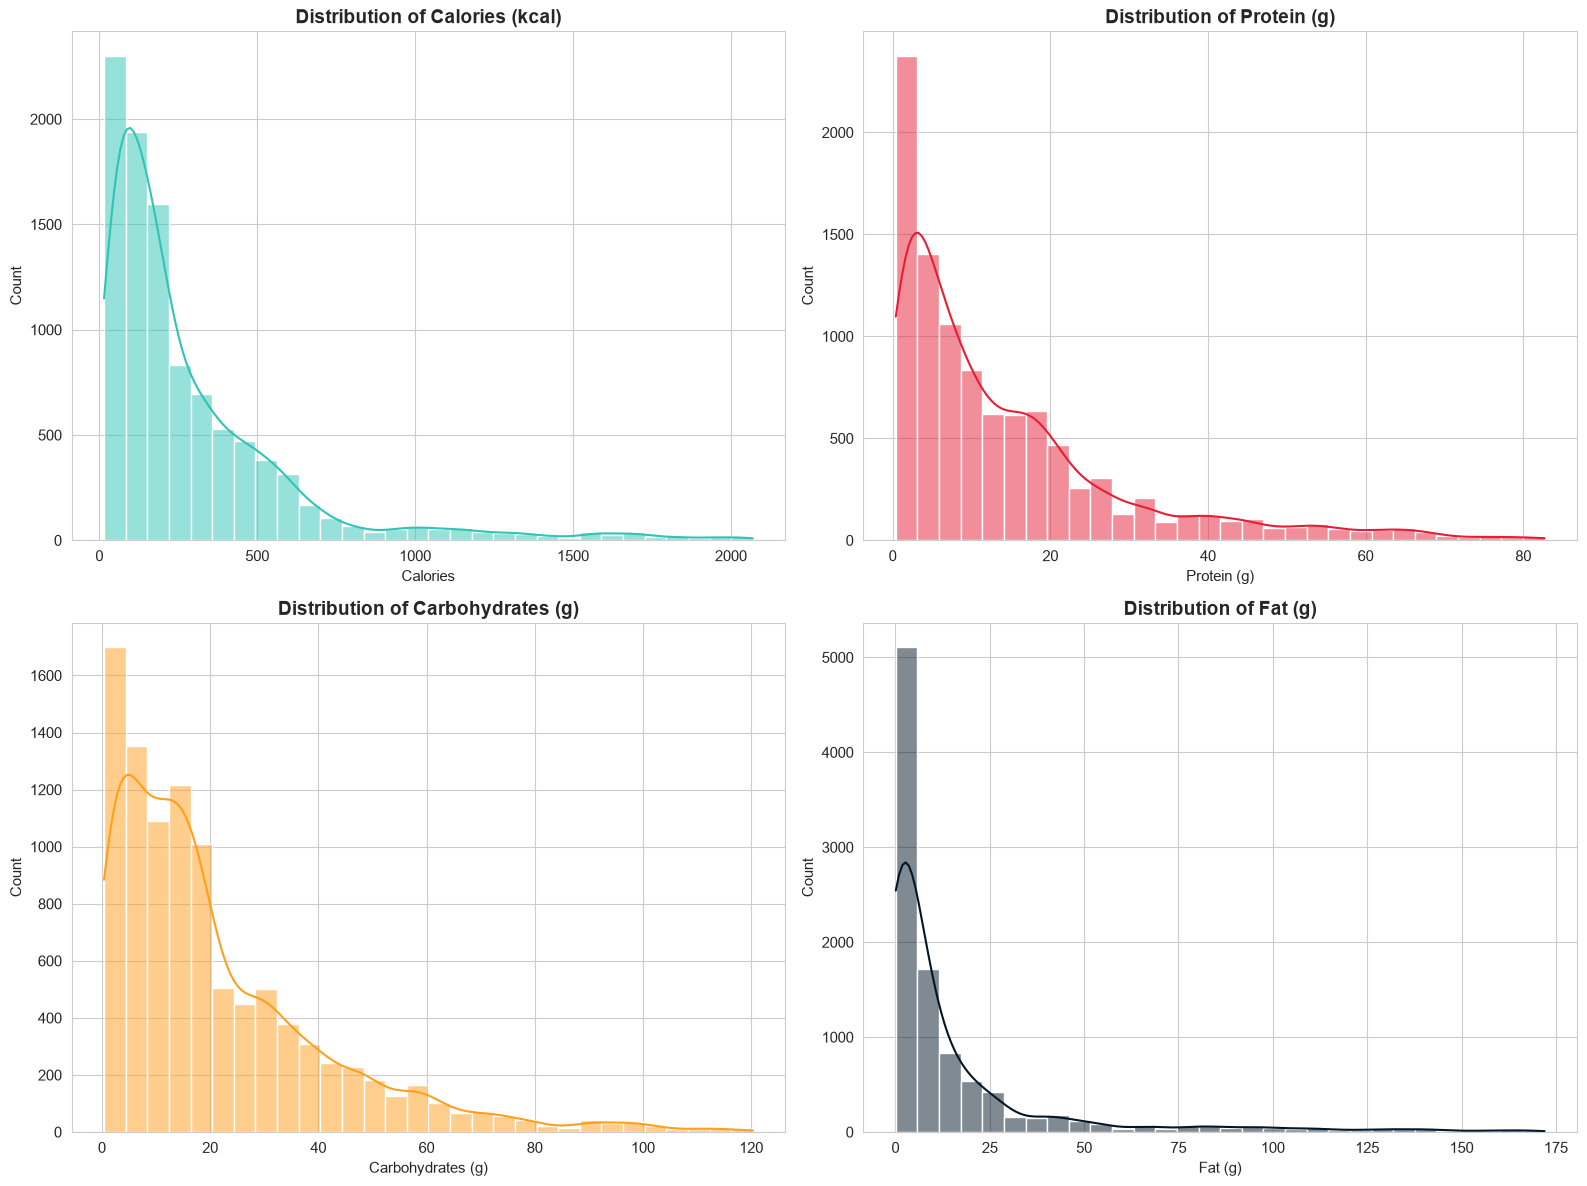

In [70]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.histplot(df['calories'], kde=True, color='#2ec4b6', ax=axes[0, 0], bins=30)
axes[0, 0].set_title('Distribution of Calories (kcal)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Calories')

sns.histplot(df['protein_g'], kde=True, color='#e71d36', ax=axes[0, 1], bins=30)
axes[0, 1].set_title('Distribution of Protein (g)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Protein (g)')

sns.histplot(df['carbs_g'], kde=True, color='#ff9f1c', ax=axes[1, 0], bins=30)
axes[1, 0].set_title('Distribution of Carbohydrates (g)', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Carbohydrates (g)')

sns.histplot(df['fat_g'], kde=True, color='#011627', ax=axes[1, 1], bins=30)
axes[1, 1].set_title('Distribution of Fat (g)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Fat (g)')

plt.tight_layout()
plt.show()

## 4. Count of Items by Category, Meal Type, and Country

Distribution of food entries across categories, meal types, and countries.

C:\Users\sushi\AppData\Local\Temp\ipykernel_5876\4150462284.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='category', data=df, order=df['category'].value_counts().index, palette='crest', ax=axes[0])
C:\Users\sushi\AppData\Local\Temp\ipykernel_5876\4150462284.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='meal_type', data=df, order=df['meal_type'].value_counts().index, palette='flare', ax=axes[1])
C:\Users\sushi\AppData\Local\Temp\ipykernel_5876\4150462284.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='country',

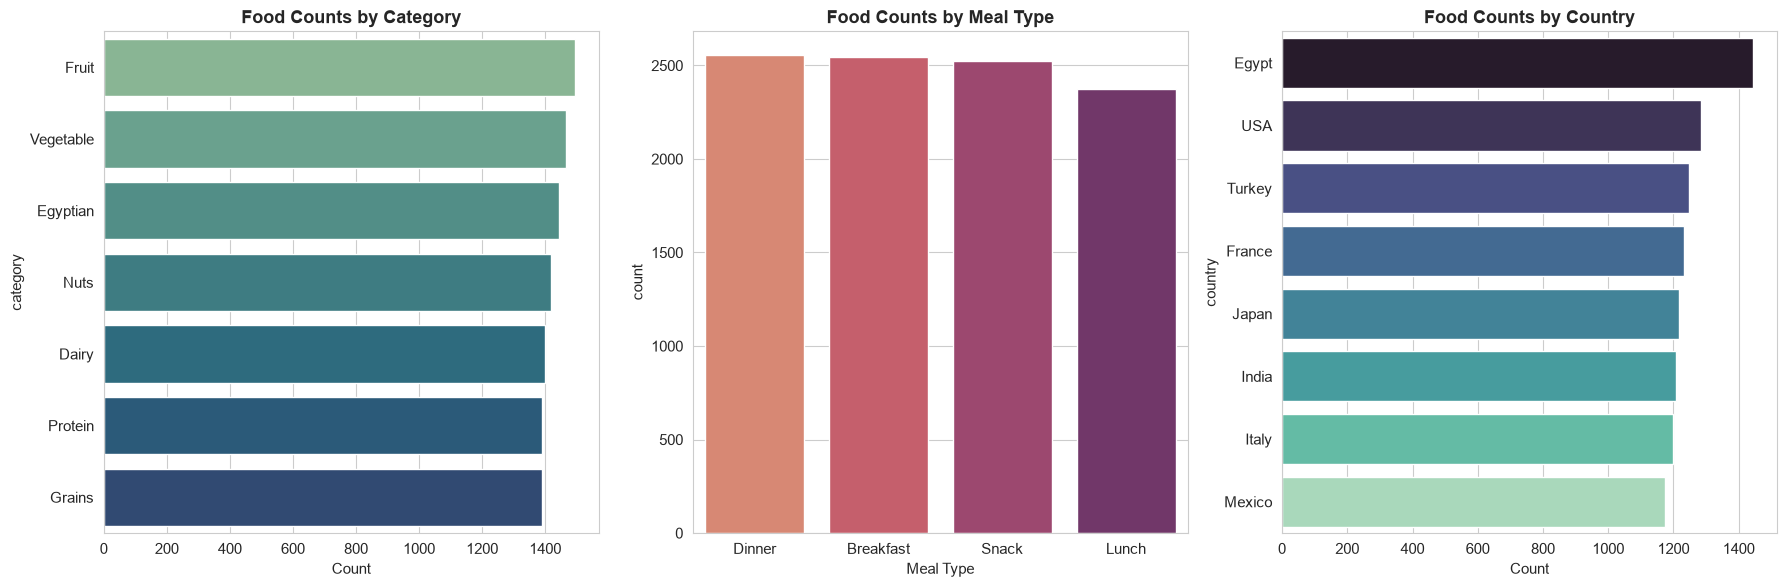

In [71]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.countplot(y='category', data=df, order=df['category'].value_counts().index, palette='crest', ax=axes[0])
axes[0].set_title('Food Counts by Category', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Count')

sns.countplot(x='meal_type', data=df, order=df['meal_type'].value_counts().index, palette='flare', ax=axes[1])
axes[1].set_title('Food Counts by Meal Type', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Meal Type')

sns.countplot(y='country', data=df, order=df['country'].value_counts().index, palette='mako', ax=axes[2])
axes[2].set_title('Food Counts by Country', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Count')

plt.tight_layout()
plt.show()

## 5. Nutrient Profiling Across Categories

Boxplots for caloric content and stacked bar chart for average macronutrient composition per category.

C:\Users\sushi\AppData\Local\Temp\ipykernel_5876\1363540967.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='category', y='calories', data=df, palette='Set2', ax=axes[0])


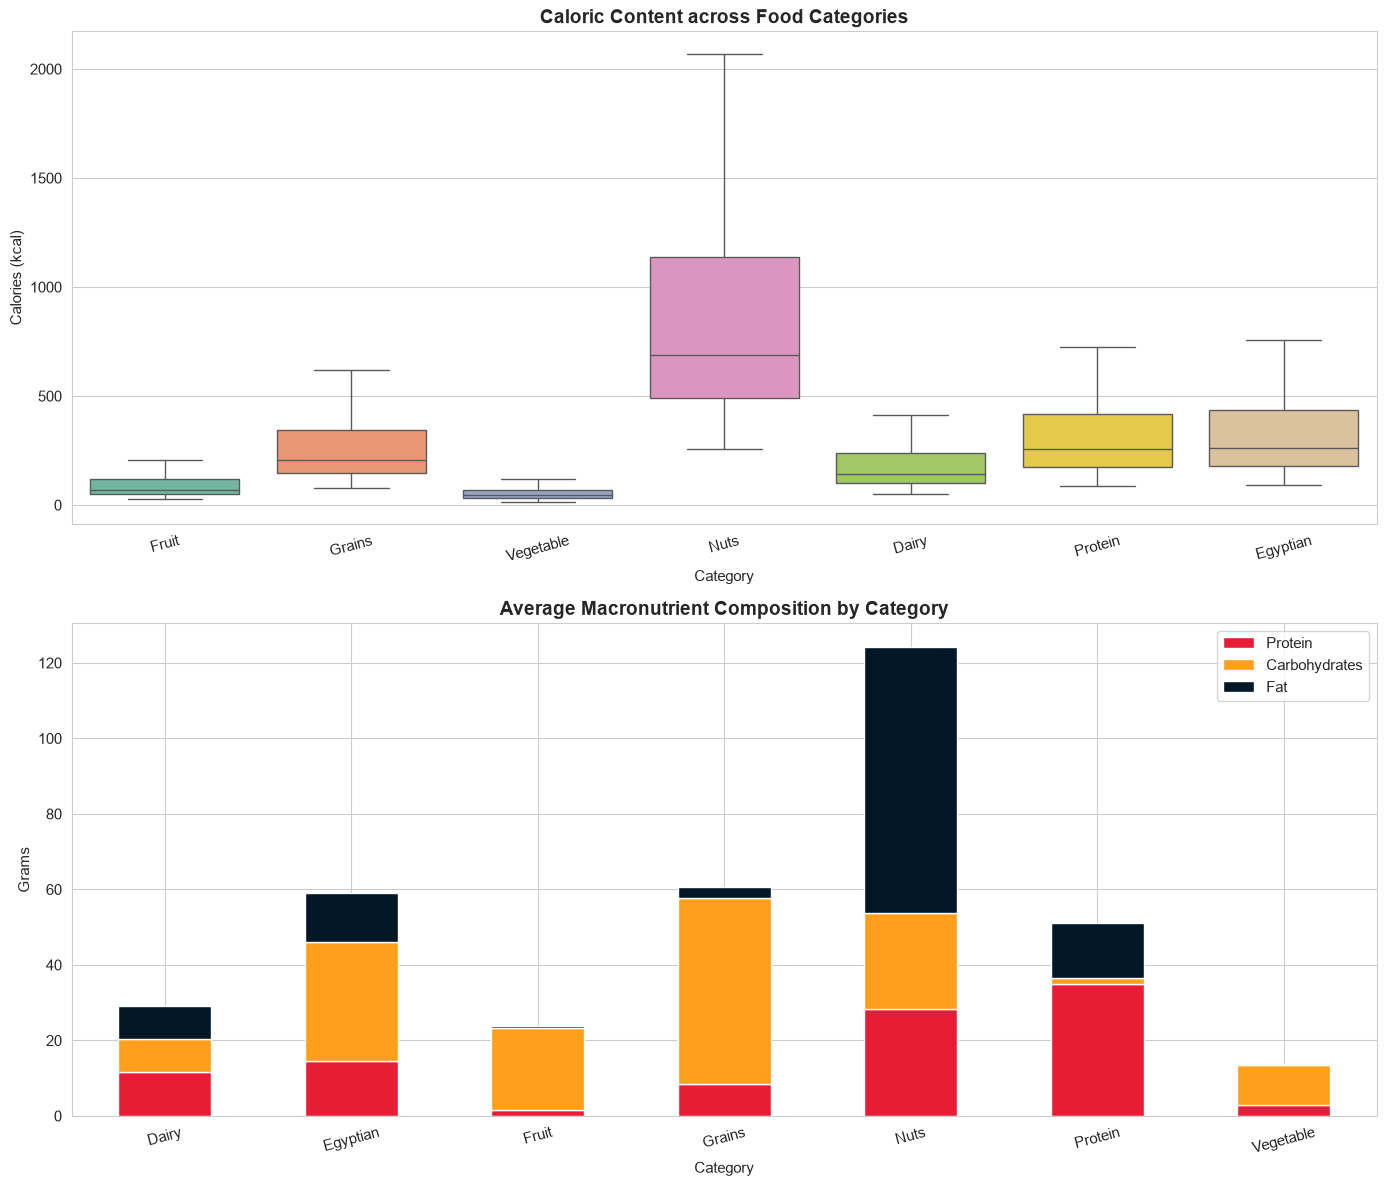

In [72]:
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

sns.boxplot(x='category', y='calories', data=df, palette='Set2', ax=axes[0])
axes[0].set_title('Caloric Content across Food Categories', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Calories (kcal)')
axes[0].tick_params(axis='x', rotation=15)

macro_by_cat = df.groupby('category')[['protein_g', 'carbs_g', 'fat_g']].mean()
macro_by_cat.plot(kind='bar', stacked=True, color=['#e71d36', '#ff9f1c', '#011627'], ax=axes[1])
axes[1].set_title('Average Macronutrient Composition by Category', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Grams')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(['Protein', 'Carbohydrates', 'Fat'], loc='upper right')

plt.tight_layout()
plt.show()

## 6. Correlation Analysis between Nutrients

Pearson correlation heatmap across key numerical columns.

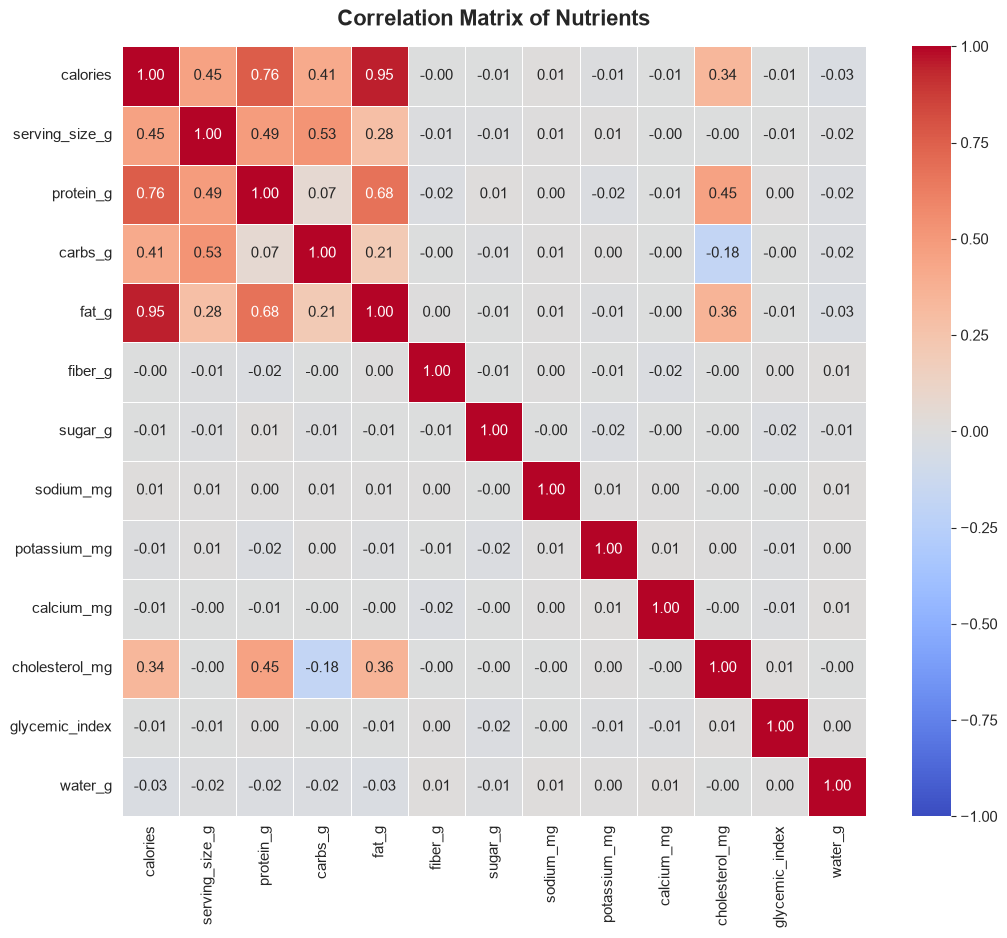

In [73]:
corr_cols = ['calories', 'serving_size_g', 'protein_g', 'carbs_g', 'fat_g',
             'fiber_g', 'sugar_g', 'sodium_mg', 'potassium_mg', 'calcium_mg',
             'cholesterol_mg', 'glycemic_index', 'water_g']

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Matrix of Nutrients', fontsize=16, fontweight='bold', pad=15)
plt.show()

## 7. Dietary Preferences Analysis

Proportion of **Vegan**, **Vegetarian**, and **Halal** food items.

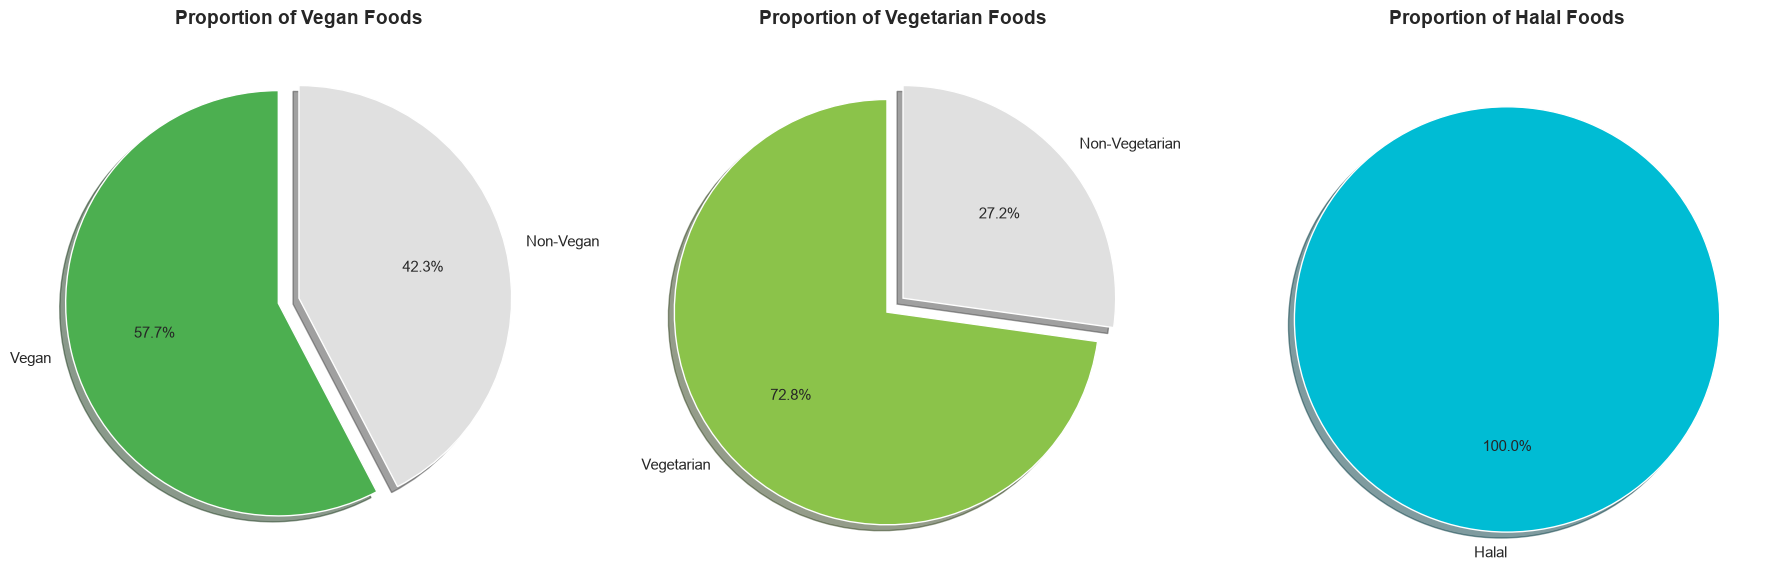

In [74]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

vegan_counts = df['is_vegan'].value_counts()
vegan_labels = ['Vegan' if x else 'Non-Vegan' for x in vegan_counts.index]
vegan_explode = [0.1 if x else 0 for x in vegan_counts.index]
axes[0].pie(vegan_counts, labels=vegan_labels, autopct='%1.1f%%',
            colors=['#4caf50', '#e0e0e0'], startangle=90, explode=vegan_explode, shadow=True)
axes[0].set_title('Proportion of Vegan Foods', fontsize=14, fontweight='bold')

veg_counts = df['is_vegetarian'].value_counts()
veg_labels = ['Vegetarian' if x else 'Non-Vegetarian' for x in veg_counts.index]
veg_explode = [0.1 if x else 0 for x in veg_counts.index]
axes[1].pie(veg_counts, labels=veg_labels, autopct='%1.1f%%',
            colors=['#8bc34a', '#e0e0e0'], startangle=90, explode=veg_explode, shadow=True)
axes[1].set_title('Proportion of Vegetarian Foods', fontsize=14, fontweight='bold')

halal_counts = df['is_halal'].value_counts()
halal_labels = ['Halal' if x else 'Non-Halal' for x in halal_counts.index]
halal_explode = [0.1 if x else 0 for x in halal_counts.index]
axes[2].pie(halal_counts, labels=halal_labels, autopct='%1.1f%%',
            colors=['#00bcd4', '#e0e0e0'], startangle=90, explode=halal_explode, shadow=True)
axes[2].set_title('Proportion of Halal Foods', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Glycemic Index and Sugar Analysis

Relationship between **Carbohydrates** and **Glycemic Index** across different food categories.

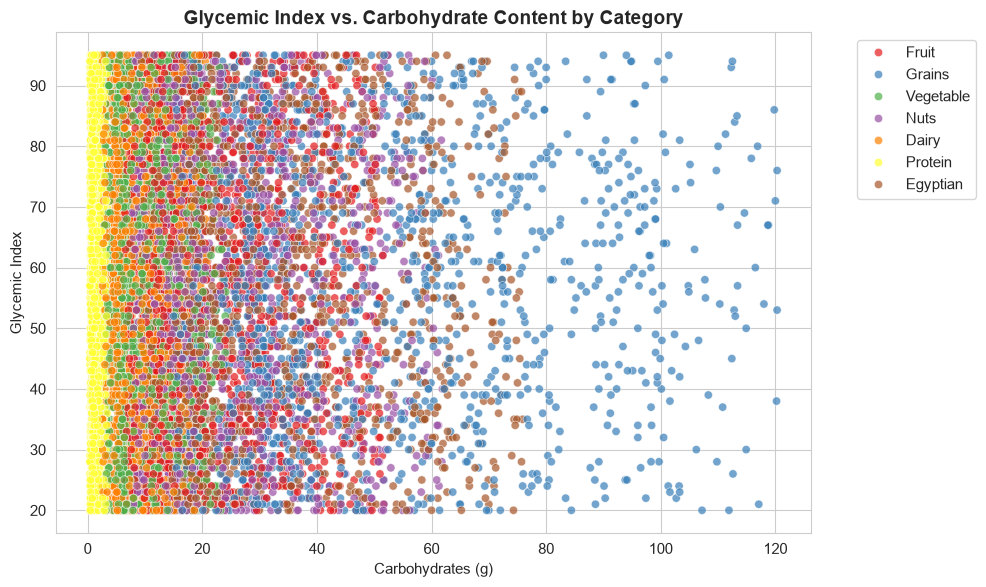

In [75]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='carbs_g', y='glycemic_index', hue='category', data=df, palette='Set1', alpha=0.7)
plt.title('Glycemic Index vs. Carbohydrate Content by Category', fontsize=14, fontweight='bold')
plt.xlabel('Carbohydrates (g)')
plt.ylabel('Glycemic Index')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

---
# Data Cleansing

In this section we systematically clean the dataset by handling:
1. Missing / null values
2. Duplicate rows
3. Invalid or negative numerical values
4. Outlier detection & treatment (IQR method)
5. Data type validation
6. Before vs. after summary

## 9. Snapshot Before Cleaning

Record the dataset shape and missing-value counts so we can compare after cleaning.

In [76]:
shape_before = df.shape
missing_before = df.isnull().sum().sum()
duplicates_before = df.duplicated().sum()

print(f'Shape before cleaning : {shape_before}')
print(f'Total missing values  : {missing_before}')
print(f'Duplicate rows        : {duplicates_before}')

Shape before cleaning : (10000, 30)
Total missing values  : 0
Duplicate rows        : 0


## 10. Handle Missing Values

In [77]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

if missing_df.empty:
    print('No missing values found in any column.')
else:
    print('Columns with missing values:')
    display(missing_df)
    cols_to_drop = missing_df[missing_df['Missing %'] > 50].index.tolist()
    if cols_to_drop:
        df.drop(columns=cols_to_drop, inplace=True)
        print(f'\nDropped columns (>50% missing): {cols_to_drop}')
    num_cols = df.select_dtypes(include='number').columns
    for col in num_cols:
        if df[col].isnull().sum() > 0:
            median_val = df[col].median()
            df[col].fillna(median_val, inplace=True)
            print(f'Filled {col} nulls with median: {median_val}')
    cat_cols = df.select_dtypes(include='object').columns
    for col in cat_cols:
        if df[col].isnull().sum() > 0:
            mode_val = df[col].mode()[0]
            df[col].fillna(mode_val, inplace=True)
            print(f'Filled {col} nulls with mode: {mode_val}')

print(f'\nRemaining missing values: {df.isnull().sum().sum()}')

No missing values found in any column.

Remaining missing values: 0


## 11. Remove Duplicate Rows

In [78]:
dupes = df.duplicated().sum()
print(f'Duplicate rows found: {dupes}')
if dupes > 0:
    df = df.drop_duplicates()
    print(f'After removal: {df.shape[0]} rows remain.')
else:
    print('No duplicates to remove.')

Duplicate rows found: 0
No duplicates to remove.


## 12. Fix Invalid / Negative Values

Nutritional values like calories, protein, fat, etc. should never be negative. We clip them to 0.

In [79]:
non_neg_cols = ['calories', 'protein_g', 'carbs_g', 'fat_g', 'fiber_g',
                'sugar_g', 'sodium_mg', 'potassium_mg', 'calcium_mg',
                'iron_mg', 'magnesium_mg', 'cholesterol_mg', 'vitamin_a_mcg',
                'vitamin_c_mg', 'vitamin_d_mcg', 'vitamin_b12_mcg',
                'zinc_mg', 'phosphorus_mg', 'water_g', 'serving_size_g']
non_neg_cols = [c for c in non_neg_cols if c in df.columns]
neg_counts = {}
for col in non_neg_cols:
    neg = (df[col] < 0).sum()
    if neg > 0:
        neg_counts[col] = neg
        df[col] = df[col].clip(lower=0)
if neg_counts:
    print('Negative values clipped to 0:')
    for col, cnt in neg_counts.items():
        print(f'  {col}: {cnt} negative values fixed')
else:
    print('No negative values found in nutritional columns.')

No negative values found in nutritional columns.


## 13. Outlier Detection & Visualization (IQR Method)

In [80]:
outlier_cols = ['calories', 'protein_g', 'carbs_g', 'fat_g', 'sugar_g', 'sodium_mg', 'cholesterol_mg']
outlier_cols = [c for c in outlier_cols if c in df.columns]
outlier_summary = []
for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append({'Column': col, 'Q1': round(Q1, 2), 'Q3': round(Q3, 2),
                            'IQR': round(IQR, 2), 'Lower Bound': round(lower, 2),
                            'Upper Bound': round(upper, 2), 'Outliers': n_outliers})
outlier_df = pd.DataFrame(outlier_summary)
print('Outlier Summary (IQR Method):')
display(outlier_df)

Outlier Summary (IQR Method):


,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outliers
0,calories,90.5,373.4,282.9,-333.85,797.75,629
1,protein_g,3.3,19.4,16.1,-20.85,43.55,675
2,carbs_g,6.4,29.8,23.4,-28.70,64.90,441
3,fat_g,0.8,16.3,15.5,-22.45,39.55,1104
4,sugar_g,5.0,14.9,9.9,-9.85,29.75,0
5,sodium_mg,291.0,889.0,598.0,-606.00,1786.00,0
6,cholesterol_mg,0.0,228.0,228.0,-342.00,570.00,0


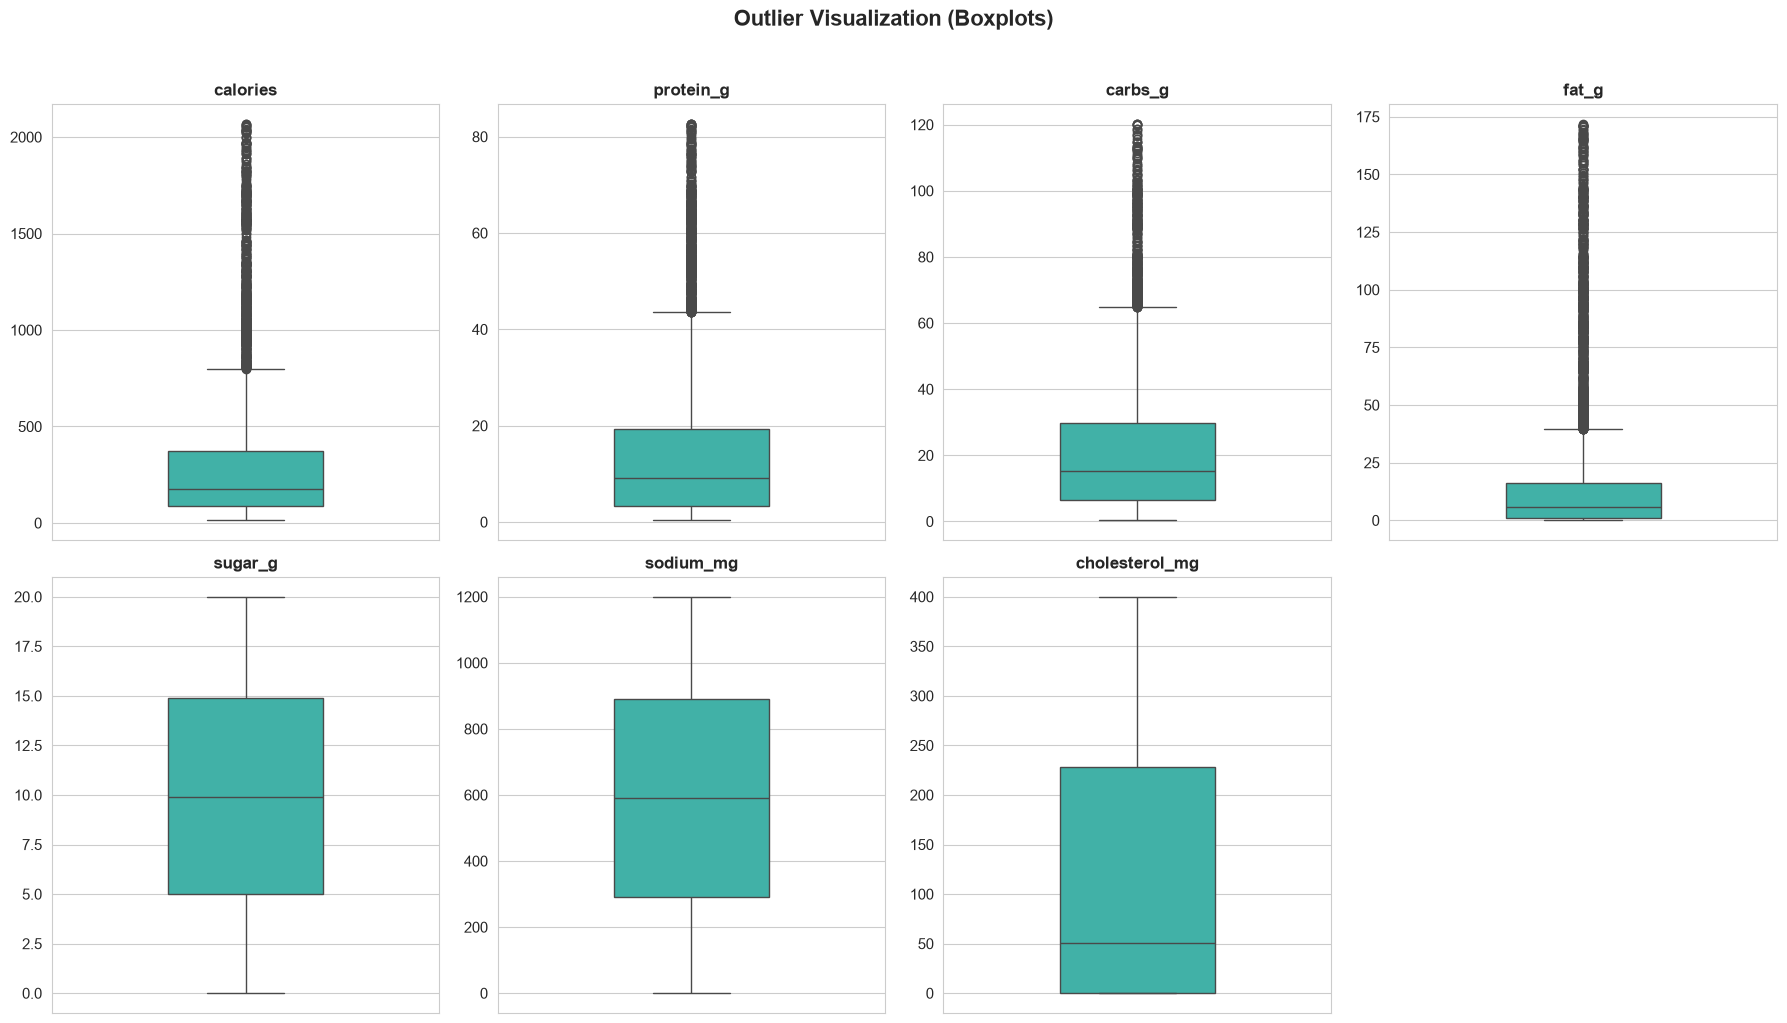

In [81]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(outlier_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='#2ec4b6', width=0.4)
    axes[i].set_title(f'{col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('')
for j in range(len(outlier_cols), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Outlier Visualization (Boxplots)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 14. Cap Outliers (Winsorization)

In [82]:
capped = []
for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before = ((df[col] < lower) | (df[col] > upper)).sum()
    if before > 0:
        df[col] = df[col].clip(lower=lower, upper=upper)
        capped.append(f'  {col}: {before} outliers capped to [{lower:.2f}, {upper:.2f}]')
if capped:
    print('Outliers capped (Winsorized):')
    print('\n'.join(capped))
else:
    print('No outliers needed capping.')

Outliers capped (Winsorized):
  calories: 629 outliers capped to [-333.85, 797.75]
  protein_g: 675 outliers capped to [-20.85, 43.55]
  carbs_g: 441 outliers capped to [-28.70, 64.90]
  fat_g: 1104 outliers capped to [-22.45, 39.55]


## 15. Data Type Validation

In [83]:
print('Current data types:')
print(df.dtypes)
print(f'\nDataset shape: {df.shape}')

Current data types:
food_id              int64
food_name              str
category               str
cuisine                str
serving_size_g       int64
calories           float64
protein_g          float64
carbs_g            float64
fat_g              float64
fiber_g            float64
sugar_g            float64
sodium_mg            int64
potassium_mg         int64
calcium_mg           int64
iron_mg            float64
magnesium_mg         int64
cholesterol_mg       int64
vitamin_a_mcg        int64
vitamin_c_mg       float64
vitamin_d_mcg      float64
vitamin_b12_mcg    float64
zinc_mg            float64
phosphorus_mg        int64
water_g            float64
is_vegan              bool
is_vegetarian         bool
is_halal              bool
glycemic_index       int64
meal_type              str
country                str
dtype: object

Dataset shape: (10000, 30)


## 16. Before vs After Cleaning Summary

In [84]:
shape_after = df.shape
missing_after = df.isnull().sum().sum()
duplicates_after = df.duplicated().sum()
summary = pd.DataFrame({
    'Metric': ['Rows', 'Columns', 'Missing Values', 'Duplicate Rows'],
    'Before': [shape_before[0], shape_before[1], missing_before, duplicates_before],
    'After':  [shape_after[0], shape_after[1], missing_after, duplicates_after]
})
summary['Change'] = summary['After'] - summary['Before']
print('=== Data Cleansing Summary ===')
display(summary)
print(f'\nCleaned dataset is ready with {shape_after[0]} rows and {shape_after[1]} columns.')

=== Data Cleansing Summary ===


,Metric,Before,After,Change
0,Rows,10000,10000,0
1,Columns,30,30,0
2,Missing Values,0,0,0
3,Duplicate Rows,0,0,0



Cleaned dataset is ready with 10000 rows and 30 columns.


---
# Feature Engineering

## 17. Calorie Density

Calorie Density stats:
count    10000.000000
mean         1.895430
std          1.553457
min          0.297000
25%          0.633000
50%          1.775000
75%          2.231000
max          6.900000
Name: calorie_density, dtype: float64


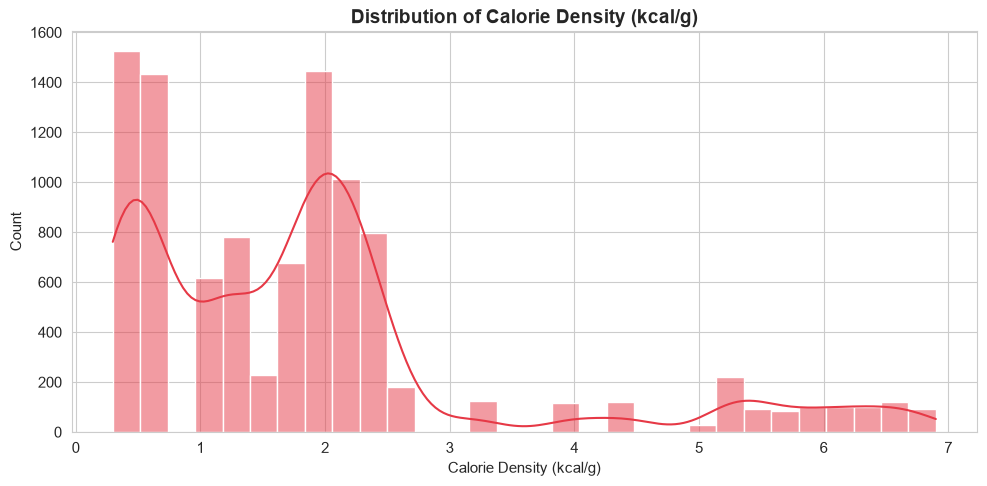

In [85]:
df['calorie_density'] = df['calories'] / df['serving_size_g'].replace(0, np.nan)
df['calorie_density'] = df['calorie_density'].fillna(0).round(3)
print('Calorie Density stats:')
print(df['calorie_density'].describe())
plt.figure(figsize=(10, 5))
sns.histplot(df['calorie_density'], kde=True, color='#e63946', bins=30)
plt.title('Distribution of Calorie Density (kcal/g)', fontsize=14, fontweight='bold')
plt.xlabel('Calorie Density (kcal/g)')
plt.tight_layout()
plt.show()

## 18. Macronutrient Calorie Percentages

In [86]:
df['protein_cal'] = df['protein_g'] * 4
df['carbs_cal'] = df['carbs_g'] * 4
df['fat_cal'] = df['fat_g'] * 9
total_macro_cal = df['protein_cal'] + df['carbs_cal'] + df['fat_cal']
total_macro_cal = total_macro_cal.replace(0, np.nan)
df['protein_pct'] = ((df['protein_cal'] / total_macro_cal) * 100).fillna(0).round(2)
df['carbs_pct'] = ((df['carbs_cal'] / total_macro_cal) * 100).fillna(0).round(2)
df['fat_pct'] = ((df['fat_cal'] / total_macro_cal) * 100).fillna(0).round(2)
df.drop(columns=['protein_cal', 'carbs_cal', 'fat_cal'], inplace=True)
print('Macronutrient calorie percentage stats:')
display(df[['protein_pct', 'carbs_pct', 'fat_pct']].describe().T)

Macronutrient calorie percentage stats:


,count,mean,std,min,25%,50%,75%,max
protein_pct,10000.0,22.053997,12.774382,4.23,13.7300,19.670,27.2100,57.44
carbs_pct,10000.0,46.236415,31.138813,1.55,19.5575,42.360,75.2625,91.61
fat_pct,10000.0,31.709540,22.765047,3.58,7.4700,38.315,49.5400,78.75


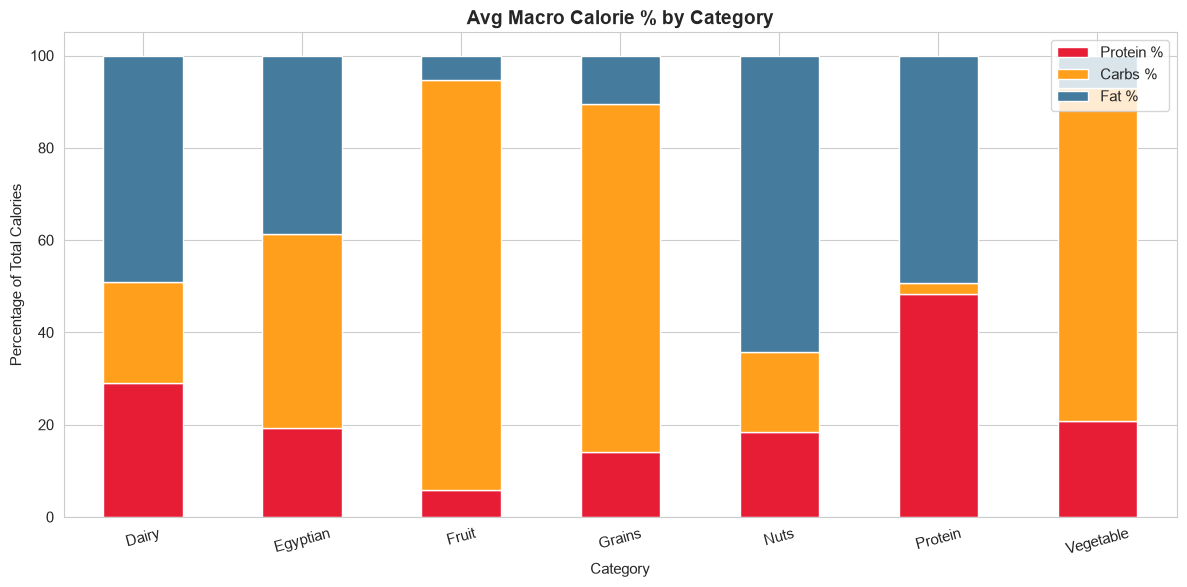

In [87]:
macro_pct_by_cat = df.groupby('category')[['protein_pct', 'carbs_pct', 'fat_pct']].mean()
macro_pct_by_cat.plot(kind='bar', stacked=True, figsize=(12, 6),
                       color=['#e71d36', '#ff9f1c', '#457b9d'])
plt.title('Avg Macro Calorie % by Category', fontsize=14, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Percentage of Total Calories')
plt.legend(['Protein %', 'Carbs %', 'Fat %'], loc='upper right')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 19. Protein-to-Fat Ratio

In [88]:
df['protein_fat_ratio'] = (df['protein_g'] / df['fat_g'].replace(0, np.nan)).fillna(0).round(3)
print('Protein-to-Fat Ratio stats:')
print(df['protein_fat_ratio'].describe())
print('\nTop 10 leanest foods (highest protein/fat ratio):')
display(df.nlargest(10, 'protein_fat_ratio')[['food_name', 'category', 'protein_g', 'fat_g', 'protein_fat_ratio']])

Protein-to-Fat Ratio stats:
count    10000.000000
mean         2.567966
std          2.033487
min          0.306000
25%          1.159000
50%          2.167000
75%          2.947000
max         11.000000
Name: protein_fat_ratio, dtype: float64

Top 10 leanest foods (highest protein/fat ratio):


,food_name,category,protein_g,fat_g,protein_fat_ratio
534,Turnip (Restaurant Style),Vegetable,1.1,0.1,11.0
612,Eggplant (Organic),Vegetable,1.1,0.1,11.0
822,Corn (Spicy),Vegetable,1.1,0.1,11.0
1909,Eggplant (Boiled),Vegetable,1.1,0.1,11.0
2510,Spinach (Baked),Vegetable,1.1,0.1,11.0
3081,Spinach (Restaurant Style),Vegetable,1.1,0.1,11.0
4190,Zucchini (Roasted),Vegetable,1.1,0.1,11.0
4306,Celery (Low Fat),Vegetable,1.1,0.1,11.0
4333,Cucumber (Traditional),Vegetable,1.1,0.1,11.0
5173,Okra (Homemade),Vegetable,1.1,0.1,11.0


## 20. Sugar-to-Carb & Fiber-to-Carb Ratios

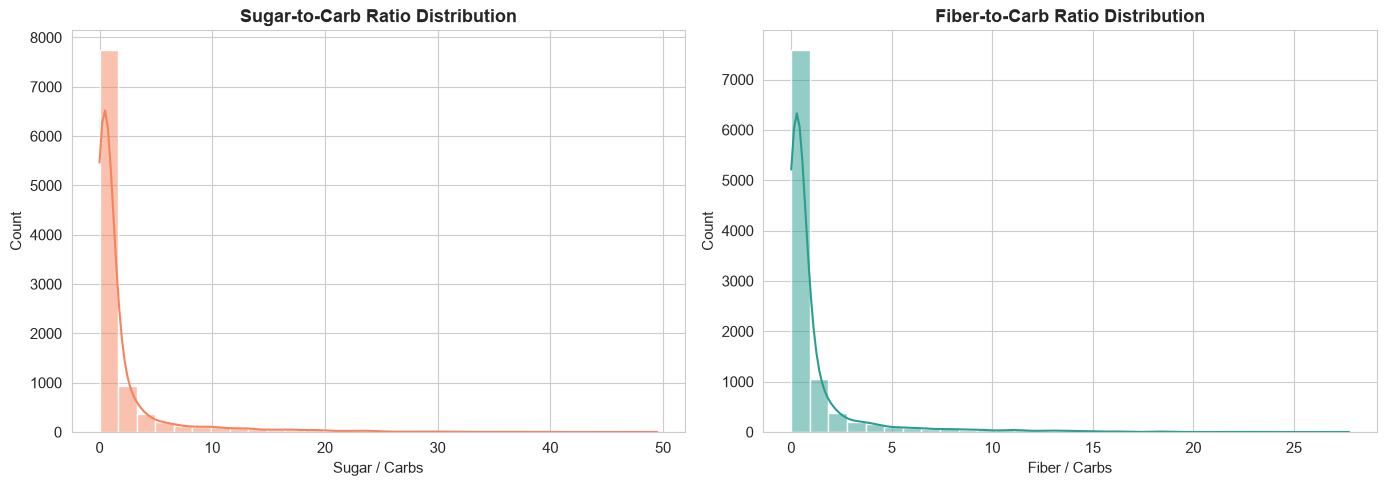

In [89]:
df['sugar_carb_ratio'] = (df['sugar_g'] / df['carbs_g'].replace(0, np.nan)).fillna(0).round(3)
df['fiber_carb_ratio'] = (df['fiber_g'] / df['carbs_g'].replace(0, np.nan)).fillna(0).round(3)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['sugar_carb_ratio'], kde=True, color='#f4845f', bins=30, ax=axes[0])
axes[0].set_title('Sugar-to-Carb Ratio Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sugar / Carbs')
sns.histplot(df['fiber_carb_ratio'], kde=True, color='#2a9d8f', bins=30, ax=axes[1])
axes[1].set_title('Fiber-to-Carb Ratio Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Fiber / Carbs')
plt.tight_layout()
plt.show()

## 21. Micronutrient Richness Score

Micronutrient Richness Score stats:
count    10000.000000
mean         5.003384
std          0.916436
min          1.711000
25%          4.377000
50%          5.004000
75%          5.634250
max          8.347000
Name: micronutrient_score, dtype: float64


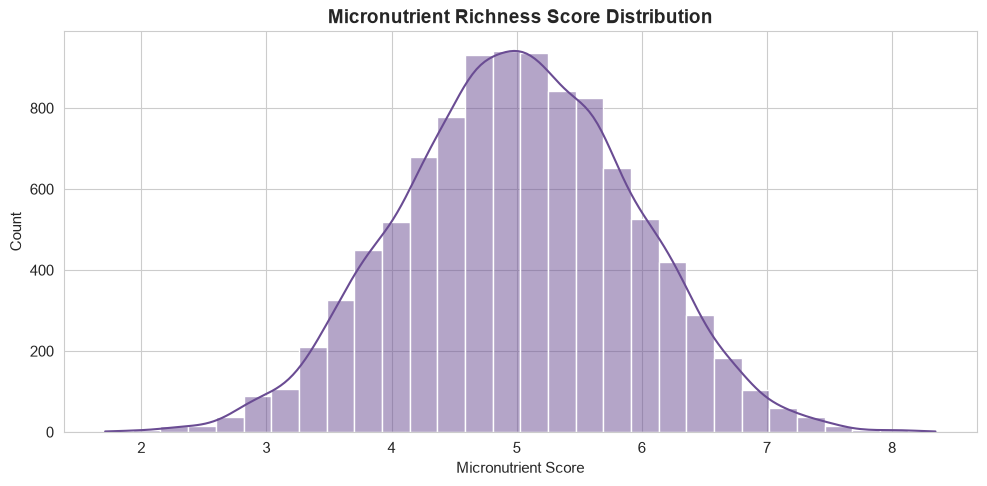

In [90]:
micro_cols = ['calcium_mg', 'iron_mg', 'magnesium_mg', 'potassium_mg',
              'vitamin_a_mcg', 'vitamin_c_mg', 'vitamin_d_mcg',
              'vitamin_b12_mcg', 'zinc_mg', 'phosphorus_mg']
micro_cols = [c for c in micro_cols if c in df.columns]
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
micro_normalized = pd.DataFrame(
    scaler.fit_transform(df[micro_cols]),
    columns=micro_cols, index=df.index)
df['micronutrient_score'] = micro_normalized.sum(axis=1).round(3)
print('Micronutrient Richness Score stats:')
print(df['micronutrient_score'].describe())
plt.figure(figsize=(10, 5))
sns.histplot(df['micronutrient_score'], kde=True, color='#6a4c93', bins=30)
plt.title('Micronutrient Richness Score Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Micronutrient Score')
plt.tight_layout()
plt.show()

## 22. Sodium-to-Potassium Ratio

In [91]:
df['sodium_potassium_ratio'] = (df['sodium_mg'] / df['potassium_mg'].replace(0, np.nan)).fillna(0).round(3)
print('Sodium-to-Potassium Ratio stats:')
print(df['sodium_potassium_ratio'].describe())
df['na_k_health'] = df['sodium_potassium_ratio'].apply(lambda x: 'Healthy (< 1.0)' if x < 1.0 else 'Unhealthy (>= 1.0)')
print(f'\nNa/K Health classification:')
print(df['na_k_health'].value_counts())

Sodium-to-Potassium Ratio stats:
count    10000.000000
mean         1.625101
std          2.266727
min          0.000000
25%          0.462000
50%          0.938000
75%          1.761250
max         23.118000
Name: sodium_potassium_ratio, dtype: float64

Na/K Health classification:
na_k_health
Healthy (< 1.0)       5339
Unhealthy (>= 1.0)    4661
Name: count, dtype: int64


## 23. Calorie Level & Glycemic Index Bins

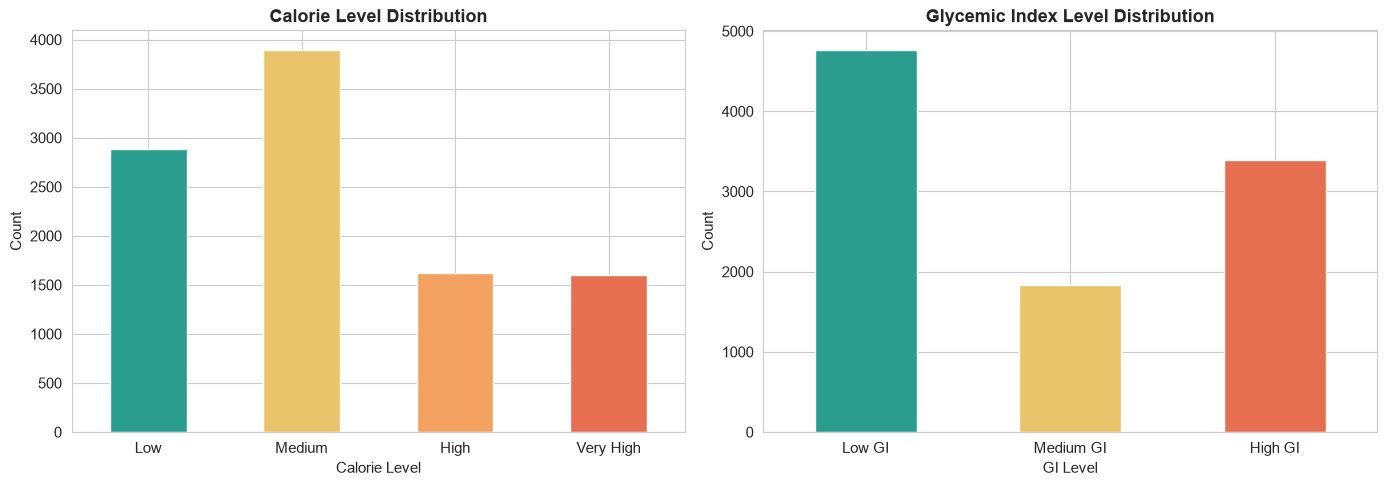

In [92]:
df['calorie_level'] = pd.cut(df['calories'],
                              bins=[0, 100, 300, 500, float('inf')],
                              labels=['Low', 'Medium', 'High', 'Very High'])
df['gi_level'] = pd.cut(df['glycemic_index'],
                         bins=[0, 55, 69, float('inf')],
                         labels=['Low GI', 'Medium GI', 'High GI'])
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df['calorie_level'].value_counts().sort_index().plot(kind='bar', color=['#2a9d8f', '#e9c46a', '#f4a261', '#e76f51'], ax=axes[0])
axes[0].set_title('Calorie Level Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Calorie Level')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
df['gi_level'].value_counts().sort_index().plot(kind='bar', color=['#2a9d8f', '#e9c46a', '#e76f51'], ax=axes[1])
axes[1].set_title('Glycemic Index Level Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('GI Level')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

## 24. Dominant Macronutrient Label

Dominant macronutrient distribution:
dominant_macro
Carbs      5426
Fat        3846
Protein     728
Name: count, dtype: int64


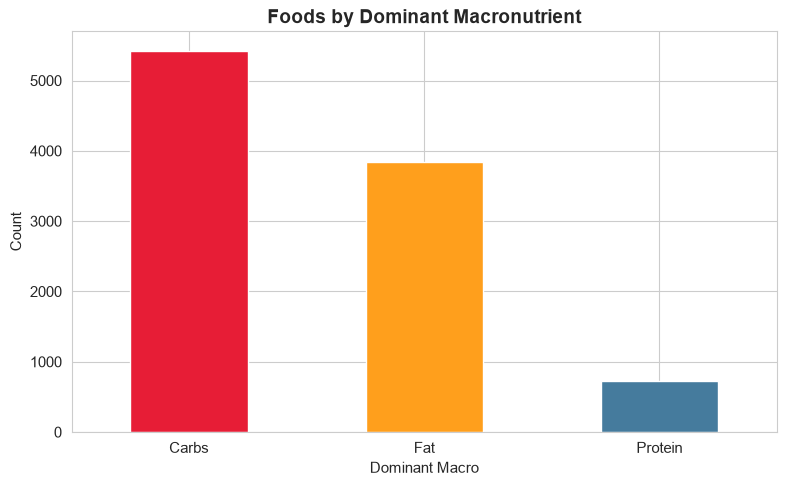

In [93]:
def dominant_macro(row):
    macros = {'Protein': row['protein_pct'], 'Carbs': row['carbs_pct'], 'Fat': row['fat_pct']}
    return max(macros, key=macros.get)
df['dominant_macro'] = df.apply(dominant_macro, axis=1)
print('Dominant macronutrient distribution:')
print(df['dominant_macro'].value_counts())
plt.figure(figsize=(8, 5))
df['dominant_macro'].value_counts().plot(kind='bar', color=['#e71d36', '#ff9f1c', '#457b9d'])
plt.title('Foods by Dominant Macronutrient', fontsize=14, fontweight='bold')
plt.xlabel('Dominant Macro')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 25. Log Transformations for Skewed Features

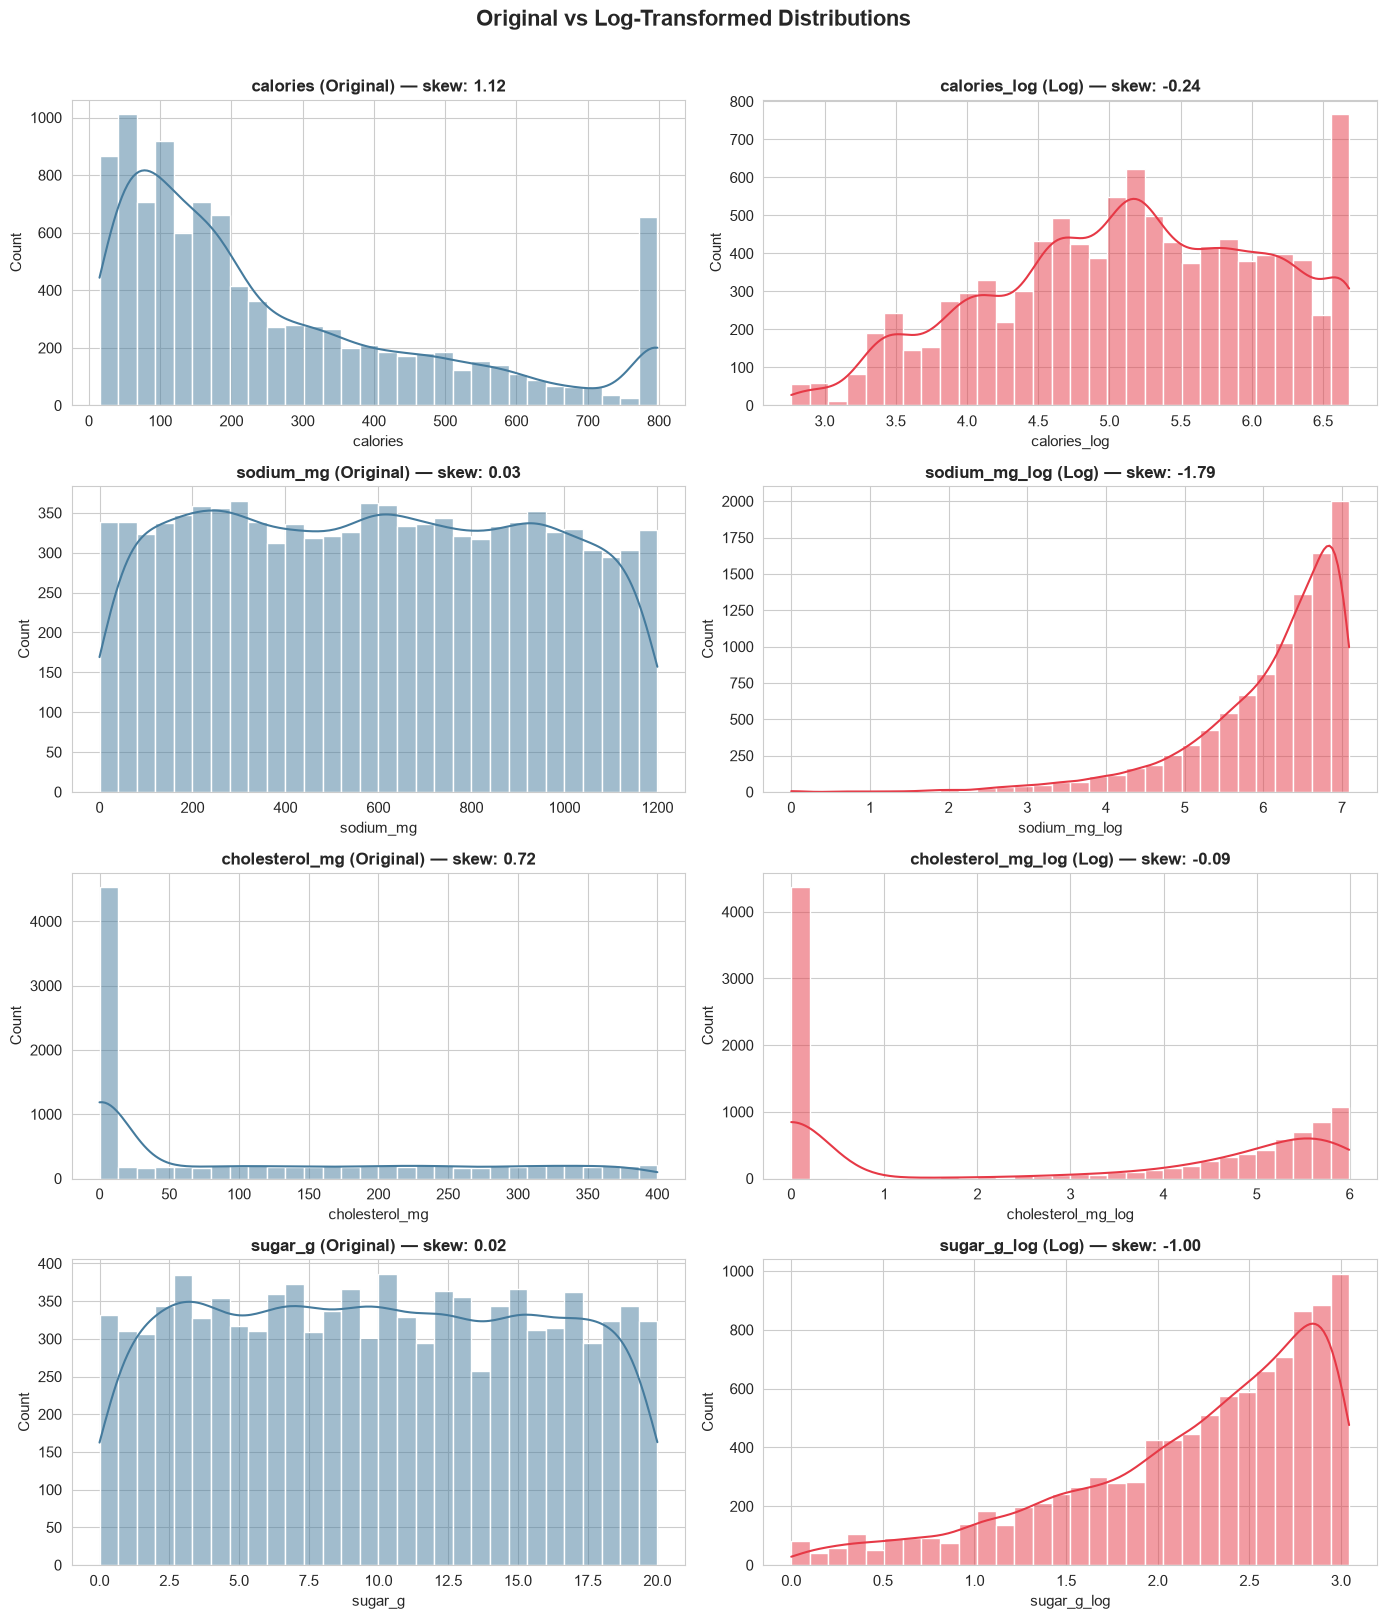

In [94]:
skew_cols = ['calories', 'sodium_mg', 'cholesterol_mg', 'sugar_g']
skew_cols = [c for c in skew_cols if c in df.columns]
fig, axes = plt.subplots(len(skew_cols), 2, figsize=(14, 4 * len(skew_cols)))
for i, col in enumerate(skew_cols):
    log_col = f'{col}_log'
    df[log_col] = np.log1p(df[col])
    sns.histplot(df[col], kde=True, color='#457b9d', bins=30, ax=axes[i, 0])
    axes[i, 0].set_title(f'{col} (Original) — skew: {df[col].skew():.2f}', fontsize=12, fontweight='bold')
    sns.histplot(df[log_col], kde=True, color='#e63946', bins=30, ax=axes[i, 1])
    axes[i, 1].set_title(f'{log_col} (Log) — skew: {df[log_col].skew():.2f}', fontsize=12, fontweight='bold')
plt.suptitle('Original vs Log-Transformed Distributions', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 26. One-Hot Encoding for Categorical Columns

In [95]:
cat_encode_cols = ['category', 'cuisine', 'meal_type', 'country']
cat_encode_cols = [c for c in cat_encode_cols if c in df.columns]
df_encoded = pd.get_dummies(df, columns=cat_encode_cols, drop_first=True, dtype=int)
print(f'Shape before encoding: {df.shape}')
print(f'Shape after encoding:  {df_encoded.shape}')
print(f'\nNew dummy columns added: {df_encoded.shape[1] - df.shape[1]}')
print('\nEncoded columns sample:')
display(df_encoded.filter(like='category_').head())

Shape before encoding: (10000, 47)
Shape after encoding:  (10000, 60)

New dummy columns added: 13

Encoded columns sample:


,category_Egyptian,category_Fruit,category_Grains,category_Nuts,category_Protein,category_Vegetable
0,0,1,0,0,0,0
1,0,1,0,0,0,0
2,0,0,1,0,0,0
3,0,0,0,0,0,1
4,0,0,0,1,0,0


## 27. Feature Engineering Summary

In [96]:
new_features = [
    ('calorie_density', 'Calories per gram of serving size'),
    ('protein_pct', '% of total macro calories from protein'),
    ('carbs_pct', '% of total macro calories from carbs'),
    ('fat_pct', '% of total macro calories from fat'),
    ('protein_fat_ratio', 'Protein grams / Fat grams'),
    ('sugar_carb_ratio', 'Sugar grams / Carb grams'),
    ('fiber_carb_ratio', 'Fiber grams / Carb grams'),
    ('micronutrient_score', 'Sum of min-max normalized vitamins & minerals'),
    ('sodium_potassium_ratio', 'Na/K ratio (< 1.0 = healthy)'),
    ('na_k_health', 'Healthy vs Unhealthy Na/K classification'),
    ('calorie_level', 'Binned: Low / Medium / High / Very High'),
    ('gi_level', 'Binned: Low GI / Medium GI / High GI'),
    ('dominant_macro', 'Which macro contributes most calories'),
    ('calories_log', 'Log1p of calories'),
    ('sodium_mg_log', 'Log1p of sodium'),
    ('cholesterol_mg_log', 'Log1p of cholesterol'),
    ('sugar_g_log', 'Log1p of sugar'),
]
feat_summary = pd.DataFrame(new_features, columns=['Feature Name', 'Description'])
feat_summary.index += 1
feat_summary.index.name = '#'
print(f'Total new features created: {len(new_features)}')
print(f'Final dataset shape: {df.shape}')
display(feat_summary)

Total new features created: 17
Final dataset shape: (10000, 47)


,Feature Name,Description
#,,
1,calorie_density,Calories per gram of serving size
2,protein_pct,% of total macro calories from protein
3,carbs_pct,% of total macro calories from carbs
4,fat_pct,% of total macro calories from fat
5,protein_fat_ratio,Protein grams / Fat grams
6,sugar_carb_ratio,Sugar grams / Carb grams
7,fiber_carb_ratio,Fiber grams / Carb grams
8,micronutrient_score,Sum of min-max normalized vitamins & minerals
9,sodium_potassium_ratio,Na/K ratio (< 1.0 = healthy)


---
# Machine Learning Models

We build **5 models** covering regression, classification, and clustering:
1. **Calorie Prediction** — Regression (Linear Regression, Random Forest, XGBoost)
2. **Food Category Classification** — Multi-class (Random Forest, XGBoost, SVM)
3. **Meal Type Prediction** — Multi-class (Random Forest, Gradient Boosting, Logistic Regression)
4. **Calorie Level Classification** — Ordinal (XGBoost, Random Forest, KNN)
5. **Food Clustering** — Unsupervised (K-Means, Hierarchical)

In [97]:
# ML Imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             accuracy_score, classification_report, confusion_matrix,
                             silhouette_score)
import warnings
warnings.filterwarnings('ignore')

print('All ML libraries loaded successfully.')

All ML libraries loaded successfully.


## 28. Model 1 — Calorie Prediction (Regression)

**Target**: `calories`  
**Features**: Nutritional columns (protein, carbs, fat, fiber, sugar, serving size, etc.)  
**Models**: Linear Regression, Random Forest Regressor

In [98]:
# Prepare data for calorie prediction
reg_features = ['serving_size_g', 'protein_g', 'carbs_g', 'fat_g', 'fiber_g',
                'sugar_g', 'sodium_mg', 'potassium_mg', 'water_g', 'glycemic_index']
reg_features = [c for c in reg_features if c in df.columns]

X_reg = df[reg_features]
y_reg = df['calories']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Linear Regression
lr = LinearRegression()
lr.fit(X_train_r, y_train_r)
lr_pred = lr.predict(X_test_r)

# Random Forest Regressor
rfr = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rfr.fit(X_train_r, y_train_r)
rfr_pred = rfr.predict(X_test_r)

# Results
reg_results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [mean_absolute_error(y_test_r, lr_pred), mean_absolute_error(y_test_r, rfr_pred)],
    'RMSE': [np.sqrt(mean_squared_error(y_test_r, lr_pred)), np.sqrt(mean_squared_error(y_test_r, rfr_pred))],
    'R² Score': [r2_score(y_test_r, lr_pred), r2_score(y_test_r, rfr_pred)]
})
print('=== Calorie Prediction Results ===')
display(reg_results)

=== Calorie Prediction Results ===


,Model,MAE,RMSE,R² Score
0,Linear Regression,26.874430,41.849808,0.962139
1,Random Forest,16.324225,24.873172,0.986626


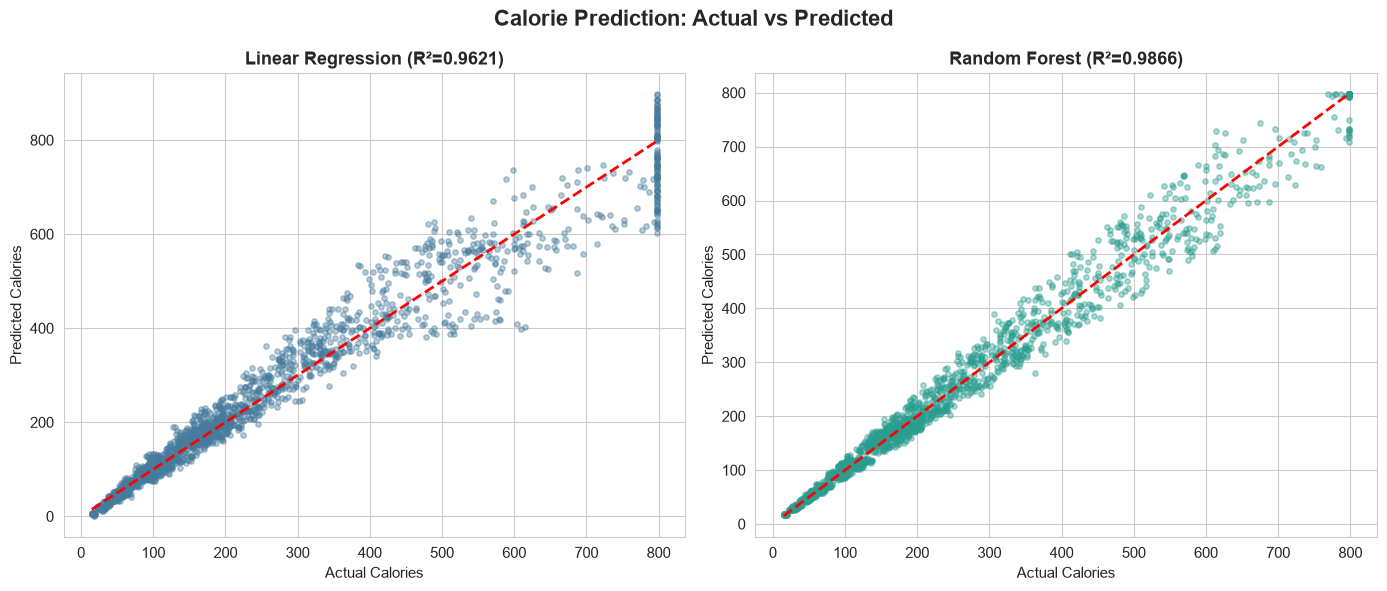

In [99]:
# Actual vs Predicted scatter
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(y_test_r, lr_pred, alpha=0.4, color='#457b9d', s=15)
axes[0].plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--', lw=2)
axes[0].set_title(f'Linear Regression (R²={r2_score(y_test_r, lr_pred):.4f})', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Actual Calories')
axes[0].set_ylabel('Predicted Calories')

axes[1].scatter(y_test_r, rfr_pred, alpha=0.4, color='#2a9d8f', s=15)
axes[1].plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--', lw=2)
axes[1].set_title(f'Random Forest (R²={r2_score(y_test_r, rfr_pred):.4f})', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Actual Calories')
axes[1].set_ylabel('Predicted Calories')

plt.suptitle('Calorie Prediction: Actual vs Predicted', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

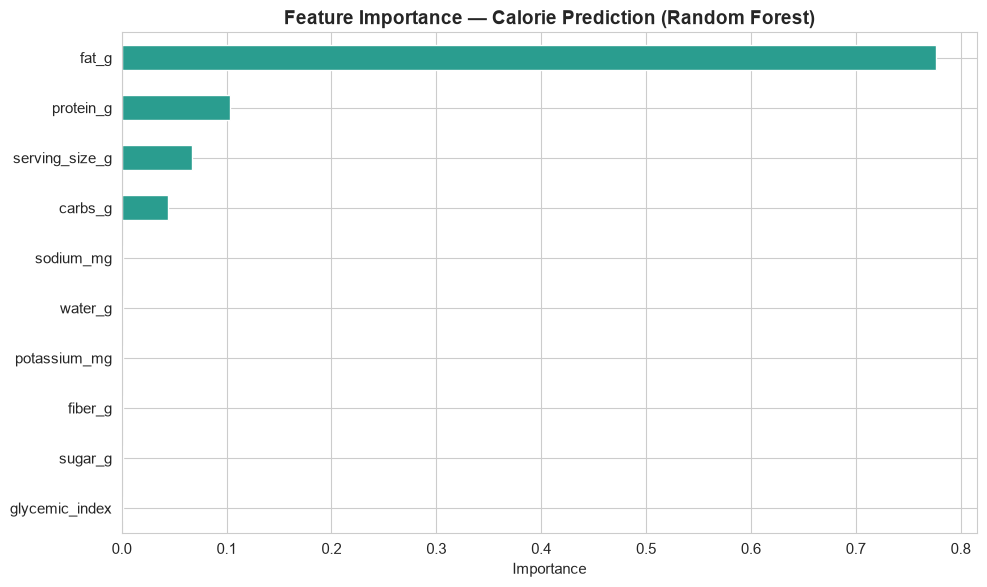

In [100]:
# Feature importance (Random Forest)
feat_imp = pd.Series(rfr.feature_importances_, index=reg_features).sort_values(ascending=True)
plt.figure(figsize=(10, 6))
feat_imp.plot(kind='barh', color='#2a9d8f')
plt.title('Feature Importance — Calorie Prediction (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 29. Model 2 — Food Category Classification

**Target**: `category` (Fruit, Grains, Vegetable, Nuts, Dairy, Protein, Egyptian)  
**Models**: Random Forest, SVM

In [101]:
# Prepare data
clf_features = ['calories', 'protein_g', 'carbs_g', 'fat_g', 'fiber_g', 'sugar_g',
                'sodium_mg', 'potassium_mg', 'calcium_mg', 'iron_mg',
                'cholesterol_mg', 'water_g', 'glycemic_index', 'serving_size_g']
clf_features = [c for c in clf_features if c in df.columns]

le_cat = LabelEncoder()
y_cat = le_cat.fit_transform(df['category'])
X_cat = df[clf_features]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_cat, y_cat, test_size=0.2, random_state=42, stratify=y_cat)

# Scale for SVM
scaler_c = StandardScaler()
X_train_cs = scaler_c.fit_transform(X_train_c)
X_test_cs = scaler_c.transform(X_test_c)

# Random Forest
rfc = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rfc.fit(X_train_c, y_train_c)
rfc_pred = rfc.predict(X_test_c)

# SVM
svc = SVC(kernel='rbf', random_state=42)
svc.fit(X_train_cs, y_train_c)
svc_pred = svc.predict(X_test_cs)

cat_results = pd.DataFrame({
    'Model': ['Random Forest', 'SVM (RBF)'],
    'Accuracy': [accuracy_score(y_test_c, rfc_pred), accuracy_score(y_test_c, svc_pred)]
})
print('=== Food Category Classification Results ===')
display(cat_results)
print('\nRandom Forest Classification Report:')
print(classification_report(y_test_c, rfc_pred, target_names=le_cat.classes_))

=== Food Category Classification Results ===


,Model,Accuracy
0,Random Forest,1.000
1,SVM (RBF),0.998



Random Forest Classification Report:
              precision    recall  f1-score   support

       Dairy       1.00      1.00      1.00       280
    Egyptian       1.00      1.00      1.00       289
       Fruit       1.00      1.00      1.00       299
      Grains       1.00      1.00      1.00       278
        Nuts       1.00      1.00      1.00       283
     Protein       1.00      1.00      1.00       278
   Vegetable       1.00      1.00      1.00       293

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



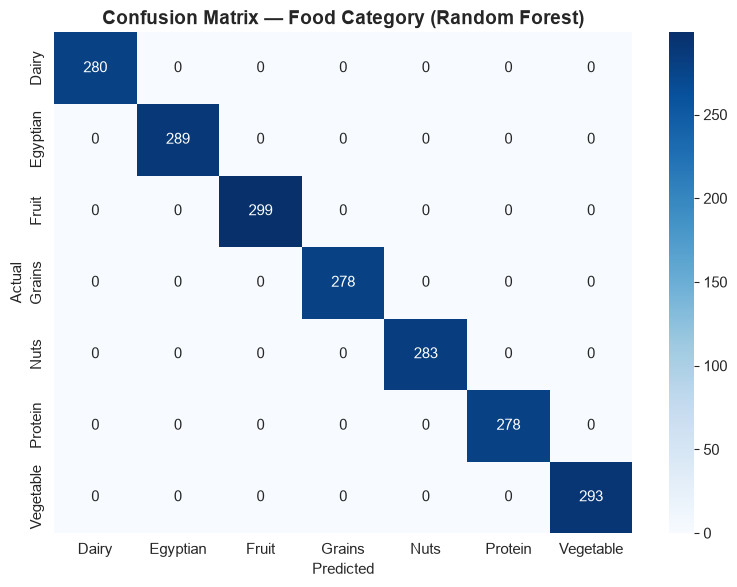

In [102]:
# Confusion matrix
cm = confusion_matrix(y_test_c, rfc_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_cat.classes_, yticklabels=le_cat.classes_)
plt.title('Confusion Matrix — Food Category (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## 30. Model 3 — Meal Type Prediction

**Target**: `meal_type` (Breakfast, Lunch, Dinner, Snack)  
**Models**: Random Forest, Gradient Boosting, Logistic Regression

In [103]:
le_meal = LabelEncoder()
y_meal = le_meal.fit_transform(df['meal_type'])
X_meal = df[clf_features]

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_meal, y_meal, test_size=0.2, random_state=42, stratify=y_meal)

# Scale for Logistic Regression
scaler_m = StandardScaler()
X_train_ms = scaler_m.fit_transform(X_train_m)
X_test_ms = scaler_m.transform(X_test_m)

# Random Forest
rf_meal = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_meal.fit(X_train_m, y_train_m)
rf_meal_pred = rf_meal.predict(X_test_m)

# Gradient Boosting
gb_meal = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_meal.fit(X_train_m, y_train_m)
gb_meal_pred = gb_meal.predict(X_test_m)

# Logistic Regression
log_meal = LogisticRegression(max_iter=1000, random_state=42)
log_meal.fit(X_train_ms, y_train_m)
log_meal_pred = log_meal.predict(X_test_ms)

meal_results = pd.DataFrame({
    'Model': ['Random Forest', 'Gradient Boosting', 'Logistic Regression'],
    'Accuracy': [accuracy_score(y_test_m, rf_meal_pred),
                 accuracy_score(y_test_m, gb_meal_pred),
                 accuracy_score(y_test_m, log_meal_pred)]
})
print('=== Meal Type Prediction Results ===')
display(meal_results)
print('\nBest model Classification Report:')
best_meal_pred = [rf_meal_pred, gb_meal_pred, log_meal_pred][meal_results['Accuracy'].argmax()]
print(classification_report(y_test_m, best_meal_pred, target_names=le_meal.classes_))

=== Meal Type Prediction Results ===


,Model,Accuracy
0,Random Forest,0.243
1,Gradient Boosting,0.251
2,Logistic Regression,0.241



Best model Classification Report:
              precision    recall  f1-score   support

   Breakfast       0.23      0.25      0.24       509
      Dinner       0.26      0.32      0.29       511
       Lunch       0.24      0.15      0.19       475
       Snack       0.26      0.28      0.27       505

    accuracy                           0.25      2000
   macro avg       0.25      0.25      0.25      2000
weighted avg       0.25      0.25      0.25      2000



## 31. Model 4 — Calorie Level Classification

**Target**: `calorie_level` (Low, Medium, High, Very High)  
**Models**: Random Forest, KNN

In [104]:
# Use features that don't include calories directly
cal_level_features = ['serving_size_g', 'protein_g', 'carbs_g', 'fat_g', 'fiber_g',
                      'sugar_g', 'sodium_mg', 'potassium_mg', 'water_g', 'glycemic_index']
cal_level_features = [c for c in cal_level_features if c in df.columns]

# Drop NaN calorie_level rows if any
df_cl = df.dropna(subset=['calorie_level'])

le_cl = LabelEncoder()
y_cl = le_cl.fit_transform(df_cl['calorie_level'])
X_cl = df_cl[cal_level_features]

X_train_cl, X_test_cl, y_train_cl, y_test_cl = train_test_split(X_cl, y_cl, test_size=0.2, random_state=42, stratify=y_cl)

# Scale for KNN
scaler_cl = StandardScaler()
X_train_cls = scaler_cl.fit_transform(X_train_cl)
X_test_cls = scaler_cl.transform(X_test_cl)

# Random Forest
rf_cl = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_cl.fit(X_train_cl, y_train_cl)
rf_cl_pred = rf_cl.predict(X_test_cl)

# KNN
knn_cl = KNeighborsClassifier(n_neighbors=5)
knn_cl.fit(X_train_cls, y_train_cl)
knn_cl_pred = knn_cl.predict(X_test_cls)

cl_results = pd.DataFrame({
    'Model': ['Random Forest', 'KNN (k=5)'],
    'Accuracy': [accuracy_score(y_test_cl, rf_cl_pred), accuracy_score(y_test_cl, knn_cl_pred)]
})
print('=== Calorie Level Classification Results ===')
display(cl_results)
print('\nRandom Forest Classification Report:')
print(classification_report(y_test_cl, rf_cl_pred, target_names=le_cl.classes_))

=== Calorie Level Classification Results ===


,Model,Accuracy
0,Random Forest,0.908
1,KNN (k=5),0.829



Random Forest Classification Report:
              precision    recall  f1-score   support

        High       0.82      0.82      0.82       324
         Low       0.96      0.92      0.94       577
      Medium       0.92      0.92      0.92       780
   Very High       0.89      0.94      0.91       319

    accuracy                           0.91      2000
   macro avg       0.90      0.90      0.90      2000
weighted avg       0.91      0.91      0.91      2000



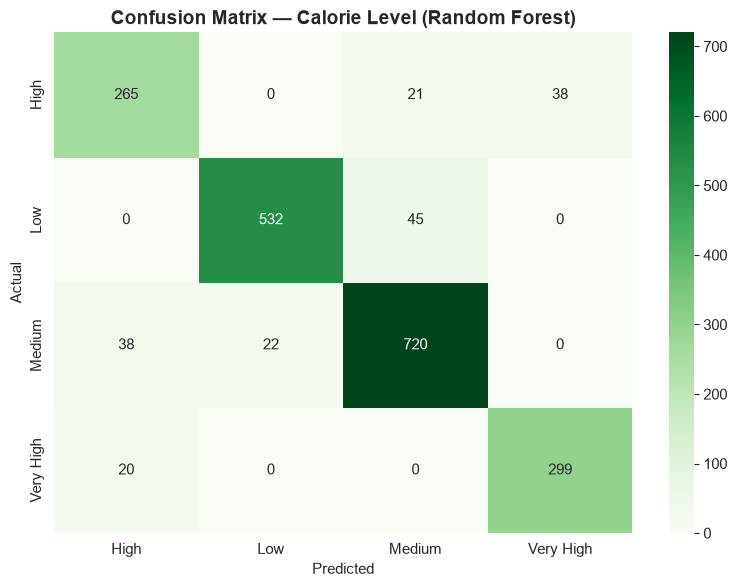

In [105]:
# Confusion matrix
cm_cl = confusion_matrix(y_test_cl, rf_cl_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_cl, annot=True, fmt='d', cmap='Greens',
            xticklabels=le_cl.classes_, yticklabels=le_cl.classes_)
plt.title('Confusion Matrix — Calorie Level (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## 32. Model 5 — Food Clustering (Unsupervised)

Group foods by nutritional similarity using **K-Means** and **Hierarchical Clustering**.

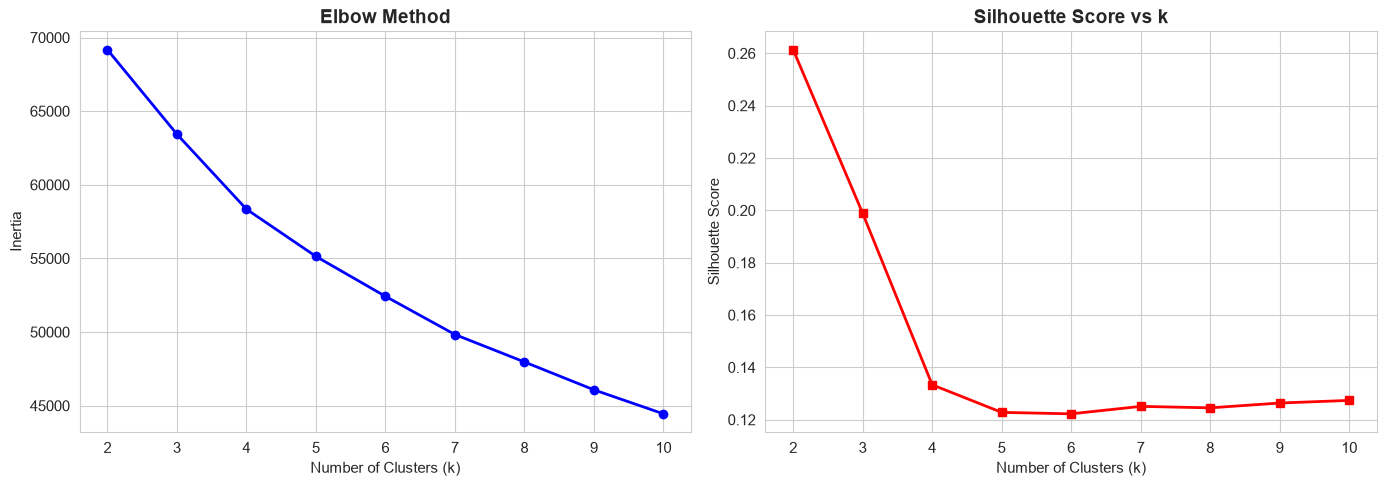

Best k by silhouette score: 2 (score: 0.2614)


In [106]:
# Select and scale features for clustering
cluster_features = ['calories', 'protein_g', 'carbs_g', 'fat_g', 'fiber_g',
                     'sugar_g', 'sodium_mg', 'potassium_mg', 'water_g']
cluster_features = [c for c in cluster_features if c in df.columns]

scaler_k = StandardScaler()
X_cluster = scaler_k.fit_transform(df[cluster_features])

# Elbow method to find optimal k
inertias = []
sil_scores = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2)
axes[0].set_title('Elbow Method', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(K_range, sil_scores, 'rs-', linewidth=2)
axes[1].set_title('Silhouette Score vs k', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

best_k = K_range[np.argmax(sil_scores)]
print(f'Best k by silhouette score: {best_k} (score: {max(sil_scores):.4f})')

In [107]:
# Fit K-Means with best k
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['cluster_kmeans'] = kmeans.fit_predict(X_cluster)

# Cluster profiles
cluster_profile = df.groupby('cluster_kmeans')[cluster_features].mean().round(2)
print(f'=== K-Means Cluster Profiles (k={best_k}) ===')
display(cluster_profile)

# Cluster sizes
print(f'\nCluster sizes:')
print(df['cluster_kmeans'].value_counts().sort_index())

=== K-Means Cluster Profiles (k=2) ===


,calories,protein_g,carbs_g,fat_g,fiber_g,sugar_g,sodium_mg,potassium_mg,water_g
cluster_kmeans,,,,,,,,,
0,143.11,7.45,17.65,4.47,6.07,9.91,590.00,629.10,57.48
1,568.20,29.64,27.72,28.48,6.00,10.02,596.12,621.37,56.45



Cluster sizes:
cluster_kmeans
0    7281
1    2719
Name: count, dtype: int64


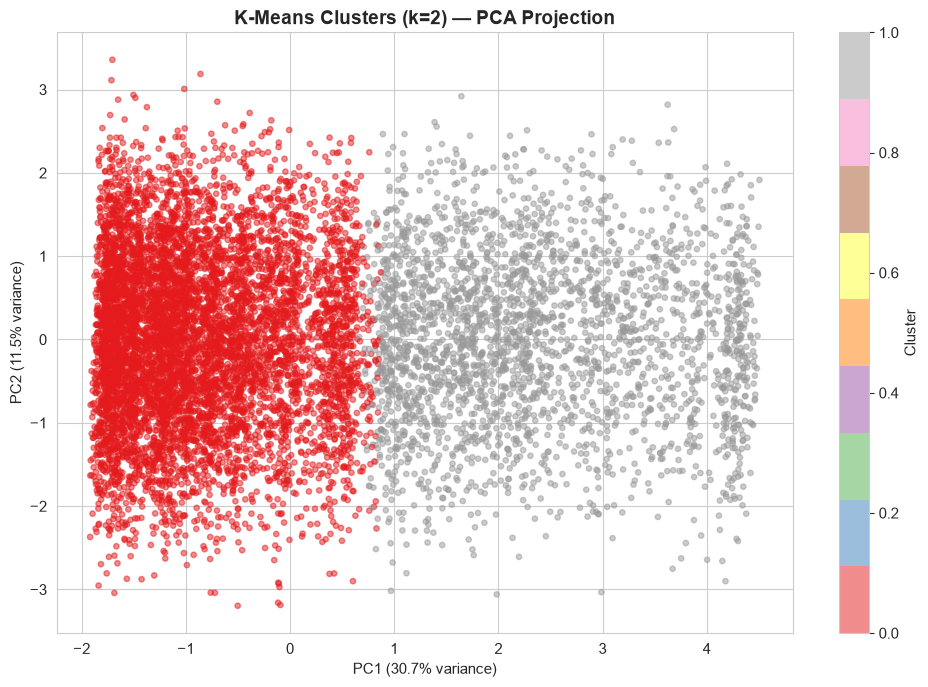

In [108]:
# Visualize clusters (PCA 2D projection)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['cluster_kmeans'],
                       cmap='Set1', alpha=0.5, s=15)
plt.colorbar(scatter, label='Cluster')
plt.title(f'K-Means Clusters (k={best_k}) — PCA Projection', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.tight_layout()
plt.show()

Cluster vs Category cross-tabulation:


category,Dairy,Egyptian,Fruit,Grains,Nuts,Protein,Vegetable
cluster_kmeans,,,,,,,
0,1272,935,1495,1215,154,744,1466
1,126,510,0,174,1263,646,0


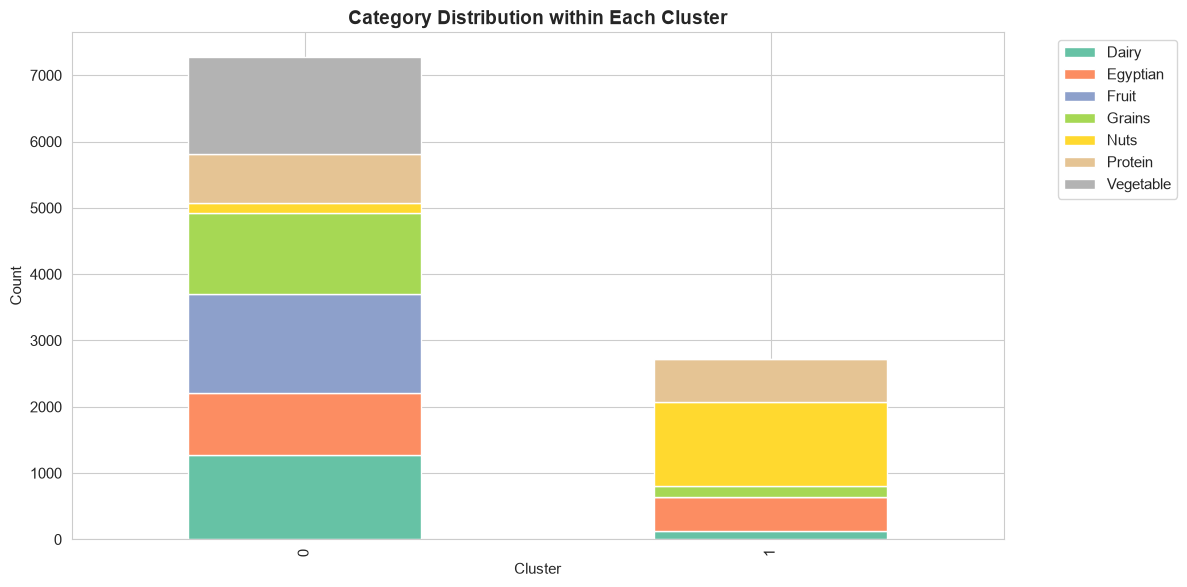

In [109]:
# Cluster vs actual category cross-tab
cross = pd.crosstab(df['cluster_kmeans'], df['category'])
print('Cluster vs Category cross-tabulation:')
display(cross)

cross.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='Set2')
plt.title('Category Distribution within Each Cluster', fontsize=14, fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 33. Model Comparison Summary

In [110]:
print('=' * 60)
print('         FINAL MODEL COMPARISON SUMMARY')
print('=' * 60)

print('\n--- Regression (Calorie Prediction) ---')
display(reg_results)

print('\n--- Classification: Food Category ---')
display(cat_results)

print('\n--- Classification: Meal Type ---')
display(meal_results)

print('\n--- Classification: Calorie Level ---')
display(cl_results)

print(f'\n--- Clustering: K-Means ---')
print(f'Optimal k: {best_k}')
print(f'Silhouette Score: {silhouette_score(X_cluster, df["cluster_kmeans"]):.4f}')

print('\n' + '=' * 60)
print('All models trained and evaluated successfully!')
print('=' * 60)

         FINAL MODEL COMPARISON SUMMARY

--- Regression (Calorie Prediction) ---


,Model,MAE,RMSE,R² Score
0,Linear Regression,26.874430,41.849808,0.962139
1,Random Forest,16.324225,24.873172,0.986626



--- Classification: Food Category ---


,Model,Accuracy
0,Random Forest,1.000
1,SVM (RBF),0.998



--- Classification: Meal Type ---


,Model,Accuracy
0,Random Forest,0.243
1,Gradient Boosting,0.251
2,Logistic Regression,0.241



--- Classification: Calorie Level ---


,Model,Accuracy
0,Random Forest,0.908
1,KNN (k=5),0.829



--- Clustering: K-Means ---
Optimal k: 2
Silhouette Score: 0.2614

All models trained and evaluated successfully!
